# Pipeline Completo: Predicción de Segundo Matrimonio
> Preprocesamiento → Modelos SVM (RBF) → Evaluación Final

## Paso 1 · Imports y Configuración

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)

# ── Configuración global ──────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.30

# Tres configuraciones de SVM a comparar
# NOTA: SVM es lento con datasets grandes.
# Se entrenará sobre una muestra representativa del 20%.
SVM_CONFIGS = [
    {
        "kernel": "rbf",
        "C": 0.1,
        "gamma": "scale",
        "class_weight": "balanced",
        "probability": True,
        "label": "Modelo 1 (C bajo - más margen)",
    },
    {
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
        "class_weight": "balanced",
        "probability": True,
        "label": "Modelo 2 (C estándar)",
    },
    {
        "kernel": "rbf",
        "C": 10.0,
        "gamma": "auto",
        "class_weight": "balanced",
        "probability": True,
        "label": "Modelo 3 (C alto - más ajuste)",
    },
]

print("✓ Librerías cargadas y configuración lista.")
print("⚠ NOTA: SVM tiene complejidad O(n²-n³). Se usará muestra del 20% para entrenamiento.")

✓ Librerías cargadas y configuración lista.
⚠ NOTA: SVM tiene complejidad O(n²-n³). Se usará muestra del 20% para entrenamiento.


## Paso 2 · Carga de Datasets Preprocesados
> Se reutilizan los CSV generados en el pipeline de Random Forest (Avances3.ipynb)

In [2]:
# ── IMPORTANTE: ajusta esta ruta a la carpeta donde están tus CSV ─────────
RUTA_DATOS = r"."   # por defecto busca en el mismo directorio del notebook
# Ejemplo Windows: RUTA_DATOS = r"C:\Users\TuUsuario\Documents\proyecto"

os.chdir(RUTA_DATOS)

X_train_final = pd.read_csv("X_train_final.csv")
y_train_final = pd.read_csv("y_train_final.csv").squeeze()
X_test_final  = pd.read_csv("X_test_final.csv")
y_test_final  = pd.read_csv("y_test_final.csv").squeeze()

cols_modelo = X_train_final.columns.tolist()

print(f"Train completo : {X_train_final.shape} | Test: {X_test_final.shape}")
print(f"Features ({len(cols_modelo)}): {cols_modelo}")
print("\nBalance train (post-SMOTE):")
print(y_train_final.value_counts())
print("\nBalance test:")
print(y_test_final.value_counts())

Train completo : (651660, 9) | Test: (153340, 9)
Features (9): ['AÑOREG', 'AÑOOCU', 'EDADHOM', 'EDADMUJ', 'DIAOCU', 'DIVORCIO', 'EDADM', 'DIFERENCIA_EDAD', 'EDAD_PROMEDIO']

Balance train (post-SMOTE):
SEGUNDO_MATRIMONIO
0    325830
1    325830
Name: count, dtype: int64

Balance test:
SEGUNDO_MATRIMONIO
0    139641
1     13699
Name: count, dtype: int64


## Paso 3 · Muestra Estratificada para SVM
> SVM escala mal con n grande (O(n²) en memoria). Usamos el 20% del train para entrenar,
> manteniendo el balance de clases. El test se evalúa completo.

In [3]:
# Muestra estratificada del 20% para entrenar SVM
X_svm_train, _, y_svm_train, _ = train_test_split(
    X_train_final, y_train_final,
    train_size=0.20,
    stratify=y_train_final,
    random_state=RANDOM_STATE
)

print(f"Muestra SVM train: {X_svm_train.shape}")
print(f"Test (completo)  : {X_test_final.shape}")
print("\nBalance muestra SVM train:")
print(y_svm_train.value_counts())
print("\nBalance muestra SVM train (%):")
print(y_svm_train.value_counts(normalize=True).mul(100).round(2))

Muestra SVM train: (130332, 9)
Test (completo)  : (153340, 9)

Balance muestra SVM train:
SEGUNDO_MATRIMONIO
1    65166
0    65166
Name: count, dtype: int64

Balance muestra SVM train (%):
SEGUNDO_MATRIMONIO
1    50.0
0    50.0
Name: proportion, dtype: float64


## Paso 4 · Funciones de Modelado y Evaluación

In [4]:
def entrenar_evaluar_svm(config: dict, X_train, y_train, X_test, y_test) -> dict:
    """Entrena un modelo SVM y retorna métricas."""
    label = config.pop("label")
    clf   = SVC(**config, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)[:, 1]

    metricas = {
        "Modelo":    label,
        "Accuracy":  round(accuracy_score(y_test, preds),  4),
        "Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, preds, zero_division=0), 4),
        "F1-score":  round(f1_score(y_test, preds, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, probs), 4),
    }
    return {"label": label, "modelo": clf, "preds": preds, "probs": probs, **metricas}


def plot_confusion_matrix(y_test, preds, label: str, ax=None):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["1er matrimonio", "2do matrimonio"]
    )
    disp.plot(ax=ax, values_format="d", colorbar=False)
    (ax or plt.gca()).set_title(f"Matriz de Confusión\n{label}")


def plot_roc(modelo, X_test, y_test, label: str, ax=None):
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax, name=label)
    (ax or plt.gca()).set_title("Curva ROC")


def plot_vectores_soporte(modelos_res: list, ax=None):
    """Compara el número de vectores de soporte entre modelos."""
    labels = [r["label"] for r in modelos_res]
    n_sv   = [r["modelo"].n_support_.sum() for r in modelos_res]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(labels, n_sv, color=sns.color_palette("Blues_r", len(labels)))
    ax.bar_label(bars, padding=4)
    ax.set_xlabel("Número de vectores de soporte")
    ax.set_title("Vectores de soporte por modelo SVM")
    plt.tight_layout()
    plt.savefig("vectores_soporte_SVM.png", dpi=150)
    plt.show()


print("✓ Funciones de modelado definidas.")

✓ Funciones de modelado definidas.


## Paso 5 · Entrenar y Comparar los 3 Modelos Base

In [5]:
resultados = []
modelos    = []

for cfg in SVM_CONFIGS:
    cfg_copy = cfg.copy()
    print(f"\nEntrenando {cfg_copy['label']}...")
    res = entrenar_evaluar_svm(cfg_copy, X_svm_train, y_svm_train, X_test_final, y_test_final)
    resultados.append(res)
    modelos.append(res)
    print(f"{'='*45}")
    print(f"  {res['label']}")
    print(f"{'='*45}")
    print(f"  Accuracy : {res['Accuracy']}")
    print(f"  Precision: {res['Precision']}")
    print(f"  Recall   : {res['Recall']}")
    print(f"  F1-score : {res['F1-score']}")
    print(f"  ROC-AUC  : {res['ROC-AUC']}")
    print(f"  Vectores de soporte: {res['modelo'].n_support_} (clase 0 | clase 1)")

df_comparacion = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("modelo", "preds", "probs")}
    for r in resultados
])

print("\n\nResumen comparativo:")
display(df_comparacion)


Entrenando Modelo 1 (C bajo - más margen)...
  Modelo 1 (C bajo - más margen)
  Accuracy : 0.5753
  Precision: 0.1609
  Recall   : 0.8903
  F1-score : 0.2725
  ROC-AUC  : 0.7601
  Vectores de soporte: [40353 40409] (clase 0 | clase 1)

Entrenando Modelo 2 (C estándar)...
  Modelo 2 (C estándar)
  Accuracy : 0.5638
  Precision: 0.1591
  Recall   : 0.9056
  F1-score : 0.2706
  ROC-AUC  : 0.7602
  Vectores de soporte: [38935 39135] (clase 0 | clase 1)

Entrenando Modelo 3 (C alto - más ajuste)...
  Modelo 3 (C alto - más ajuste)
  Accuracy : 0.5585
  Precision: 0.158
  Recall   : 0.9101
  F1-score : 0.2692
  ROC-AUC  : 0.7594
  Vectores de soporte: [38283 38561] (clase 0 | clase 1)


Resumen comparativo:


,label,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Modelo 1 (C bajo - más margen),Modelo 1 (C bajo - más margen),0.5753,0.1609,0.8903,0.2725,0.7601
1,Modelo 2 (C estándar),Modelo 2 (C estándar),0.5638,0.1591,0.9056,0.2706,0.7602
2,Modelo 3 (C alto - más ajuste),Modelo 3 (C alto - más ajuste),0.5585,0.1580,0.9101,0.2692,0.7594


## Paso 6 · Matrices de Confusión — Comparación Visual

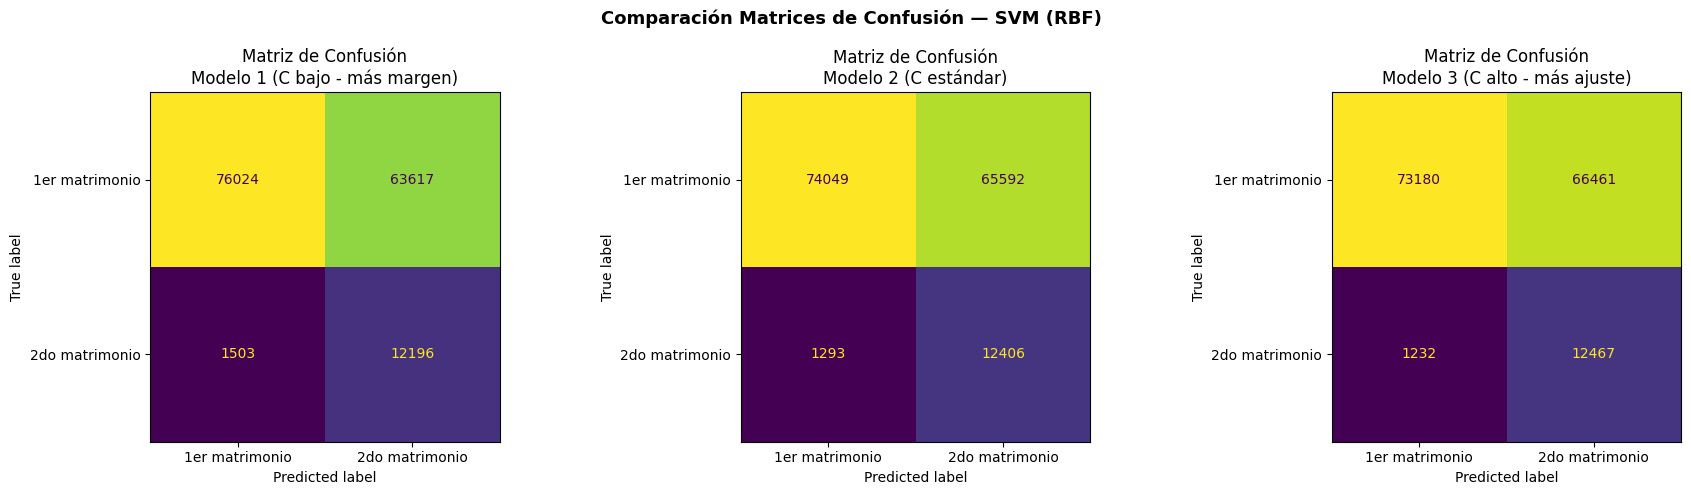

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, res in zip(axes, modelos):
    plot_confusion_matrix(y_test_final, res["preds"], res["label"], ax=ax)
plt.suptitle("Comparación Matrices de Confusión — SVM (RBF)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices_SVM.png", dpi=150)
plt.show()

## Paso 7 · Curvas ROC y Vectores de Soporte

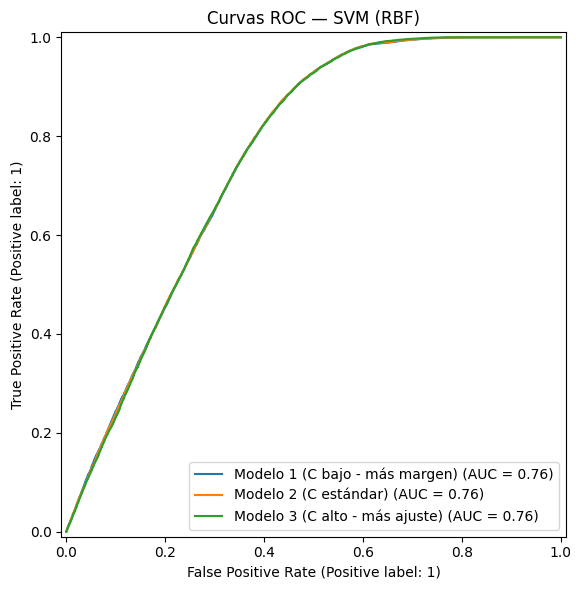

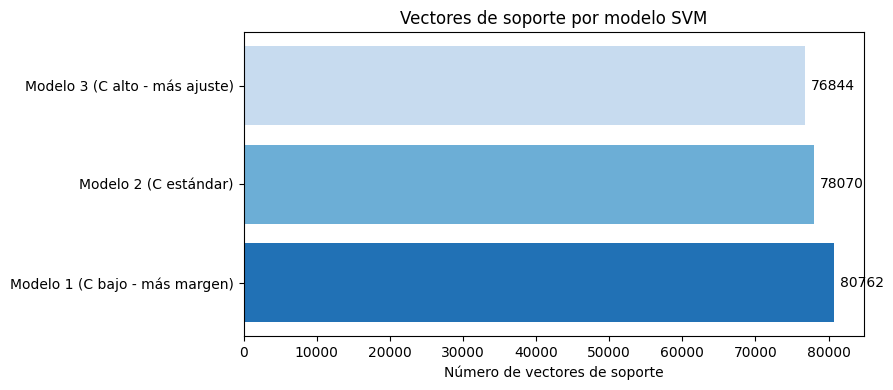

In [7]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))
for res in modelos:
    RocCurveDisplay.from_estimator(
        res["modelo"], X_test_final, y_test_final, ax=ax, name=res["label"]
    )
ax.set_title("Curvas ROC — SVM (RBF)")
plt.tight_layout()
plt.savefig("roc_SVM.png", dpi=150)
plt.show()

# Vectores de soporte (métrica única de SVM)
plot_vectores_soporte(modelos)

## Paso 8 · Búsqueda de Hiperparámetros (RandomizedSearchCV)

In [ ]:
param_dist = {
    "C":            [0.01, 0.1, 1.0, 10.0, 100.0],
    "kernel":       ["rbf", "linear"],
    "gamma":        ["scale", "auto", 0.001, 0.01, 0.1],
    "class_weight": ["balanced", None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_svm = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=5,           # menos iteraciones porque SVM es más lento
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Búsqueda sobre la muestra del 20% (misma que se usó para entrenar)
search_svm.fit(X_svm_train, y_svm_train)

print(f"\n✓ Mejores hiperparámetros encontrados:")
print(search_svm.best_params_)
print(f"  Mejor F1 CV: {search_svm.best_score_:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits


## Paso 9 · Modelo Optimizado — Entrenamiento Final

In [ ]:
# Reentrenar con los mejores parámetros sobre la muestra completa de train
modelo_opt_svm = SVC(
    **search_svm.best_params_,
    probability=True,
    random_state=RANDOM_STATE,
)
modelo_opt_svm.fit(X_svm_train, y_svm_train)

pred_opt  = modelo_opt_svm.predict(X_test_final)
probs_opt = modelo_opt_svm.predict_proba(X_test_final)[:, 1]
label_opt = "Modelo Optimizado SVM"

print(f"\n{'='*45}")
print(f"  MODELO OPTIMIZADO — SVM (RBF)")
print(f"{'='*45}")
print(classification_report(y_test_final, pred_opt, zero_division=0))
print(f"  Accuracy : {accuracy_score(y_test_final, pred_opt):.4f}")
print(f"  F1       : {f1_score(y_test_final, pred_opt, average='weighted'):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test_final, probs_opt):.4f}")
print(f"  Vectores de soporte: {modelo_opt_svm.n_support_} (clase 0 | clase 1)")
print(f"  Hiperparámetros: {search_svm.best_params_}")

## Paso 10 · Evaluación Final del Mejor Modelo

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(y_test_final, pred_opt, label_opt, ax=axes[0])
plot_roc(modelo_opt_svm, X_test_final, y_test_final, label_opt, ax=axes[1])
plt.suptitle(f"Evaluación Final — {label_opt}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("evaluacion_final_SVM.png", dpi=150)
plt.show()

## Paso 11 · Guardado de Resultados

In [ ]:
# Consolidar resultados incluyendo el modelo optimizado
fila_opt = {
    "Modelo":    label_opt,
    "Accuracy":  round(accuracy_score(y_test_final, pred_opt), 4),
    "Precision": round(precision_score(y_test_final, pred_opt, zero_division=0), 4),
    "Recall":    round(recall_score(y_test_final, pred_opt, zero_division=0), 4),
    "F1-score":  round(f1_score(y_test_final, pred_opt, zero_division=0), 4),
    "ROC-AUC":   round(roc_auc_score(y_test_final, probs_opt), 4),
}
df_comparacion = pd.concat(
    [df_comparacion, pd.DataFrame([fila_opt])], ignore_index=True
)

df_comparacion.to_csv("comparacion_modelos_SVM.csv", index=False)

print("\n✓ Archivos guardados:")
print("  comparacion_modelos_SVM.csv")
print("  evaluacion_final_SVM.png")
print("  confusion_matrices_SVM.png")
print("  roc_SVM.png")
print("  vectores_soporte_SVM.png")

print("\nComparación final de todos los modelos SVM:")
display(df_comparacion)